# Create Bar Plots Showing the Grid Response in the Three Pairs of Case Studies


In [1]:
# Start by importing the packages we need:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Suppress Warnings


In [2]:
# Suppress future warnings:
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None


## Set the Directory Structure

In [132]:
# Set the data input and output directories:
events_data_input_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/thermal_events_data/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/figures/'


## Calculate and Plot the Stress Metrics for the Case Studies


In [133]:
def plot_case_studies(event_list: list, event_label: list, hw_cs: str, events_data_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Extract the heat wave or cold snap library data for a given NERC region:
    if hw_cs == 'HW':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'hw_library_expanded.csv'))
    elif hw_cs == 'CS':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'cs_library_expanded.csv'))

    # Loop over the list of events and extract the data for that event into a combined dataframe:
    for i in range(len(event_list)):
            
        # Subset to just the data for event in the list:
        subset_df = hw_cs_df[(hw_cs_df['UID'] == event_list[i])].copy()
        
        # Aggregate the output into a new dataframe:
        if i == 0:
           event_df = subset_df
        else:
           event_df = pd.concat([event_df, subset_df])

    # Add in the row number for plotting:
    event_df['Row'] = range(len(event_df))
    event_df['Row'] = event_df['Row']+ 1

    # Reset the index:
    event_df.reset_index(inplace=True, drop=True)
    
    # Add in the event label:
    for i in range(len(event_df)):
        event_df.at[i, 'Label'] = event_label[i]
        
    # Drop columns to make it easier to see the data:
    event_df.drop(['UID', 'NERC', 'Center', 'Center_DOY', 'Duration', 'Regions_Impacted', 'Renew_at_Peak'], axis=1, inplace=True)

    # Make the event plot:
    plt.figure(figsize=(22, 22))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True

    ax1 = plt.subplot(221)
    event_df.plot.bar(x='Label',y=['Max_LMP'], stacked=False, color=['gray'], ax=ax1)
    ax1.legend_ = None
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Maximum Locational Marginal Price During Event [$/MW]')
    plt.title('a)', loc='left', fontsize=18)
    plt.title('Locational Marginal Prices')

    ax2 = plt.subplot(222)
    event_df.plot.bar(x='Label',y=['Max_Load_Shed'], stacked=False, color=['gray'], ax=ax2)
    ax2.legend_ = None
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Maximum Unserved Energy During Event [MW]')
    plt.title('b)', loc='left', fontsize=18)
    plt.title('Unserved Energy')

    ax3 = plt.subplot(223)
    event_df.plot.bar(x='Label',y=['Import_at_Peak'], stacked=False, color=['gray'], ax=ax3)
    ax3.legend_ = None
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Net Imports at Time of Peak Demand [MW]')
    plt.title('c)', loc='left', fontsize=18)
    plt.title('Imports')
    
    ax4 = plt.subplot(224)
    event_df.plot.bar(x='Label',y=['Coal_at_Peak','Gas_at_Peak','Hydro_at_Peak','Other_at_Peak','Solar_at_Peak','Wind_at_Peak'], stacked=True, 
                      label=['Coal','Gas','Hydro','Other','Solar','Wind'],
                      color=['k','brown','b','m','r','g'], ax=ax4)
    plt.xticks(rotation=0)
    plt.xlabel('') 
    plt.ylabel('Total Generation at Time of Peak Demand [MW]')
    plt.title('d)', loc='left', fontsize=18)
    plt.title('Generation Mix')

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + 'Case_Studies.png'), dpi=image_resolution, bbox_inches='tight')
        
    return event_df


,Region,Start,End,T_Max_Min,WECC_Load_Peak,Region_Load_Peak,Max_LMP,Max_Load_Shed,Total_at_Peak,Coal_at_Peak,Gas_at_Peak,Hydro_at_Peak,Other_at_Peak,Solar_at_Peak,Wind_at_Peak,Import_at_Peak,Load_Shed_at_Peak,LMP_at_Peak,Row,Label
0,CA,2006-06-25,2006-06-26,91.09,147163.0,61371.0,212.45,0.0,50133.2,55.0,31609.0,5720.0,5805.0,6135.0,808.0,9774.0,0.0,67.47,1,ST1-CA
1,CA,2015-09-09,2015-09-11,91.44,141767.0,61378.0,1998.53,515.0,49129.2,55.0,34132.0,2622.0,7770.0,3872.0,678.0,10964.0,0.0,276.57,2,ST2-CA
2,PNW,2017-08-08,2017-08-10,85.61,145702.0,26686.0,2018.80,3521.0,20209.6,888.3,6336.0,10745.0,2017.0,222.0,2.0,4075.0,0.0,45.72,3,SE1-PNW
3,PNW,2005-07-27,2005-07-28,85.80,148581.0,26696.0,2124.27,4134.0,28383.3,1628.5,7036.0,17358.0,2124.0,234.0,3.0,-2973.0,0.0,470.08,4,SE2-PNW
4,GB,2016-06-28,2016-06-28,84.16,152777.0,20254.0,267.13,0.0,12297.1,3720.1,2501.0,1196.0,1111.0,1764.0,2006.0,-2918.0,0.0,31.12,5,ED1-GB
5,GB,1994-07-25,1994-07-31,87.12,148349.0,20518.0,2040.04,520.0,12448.9,3750.1,3667.0,1113.0,1544.0,1702.0,673.0,-214.0,0.0,50.29,6,ED2-GB


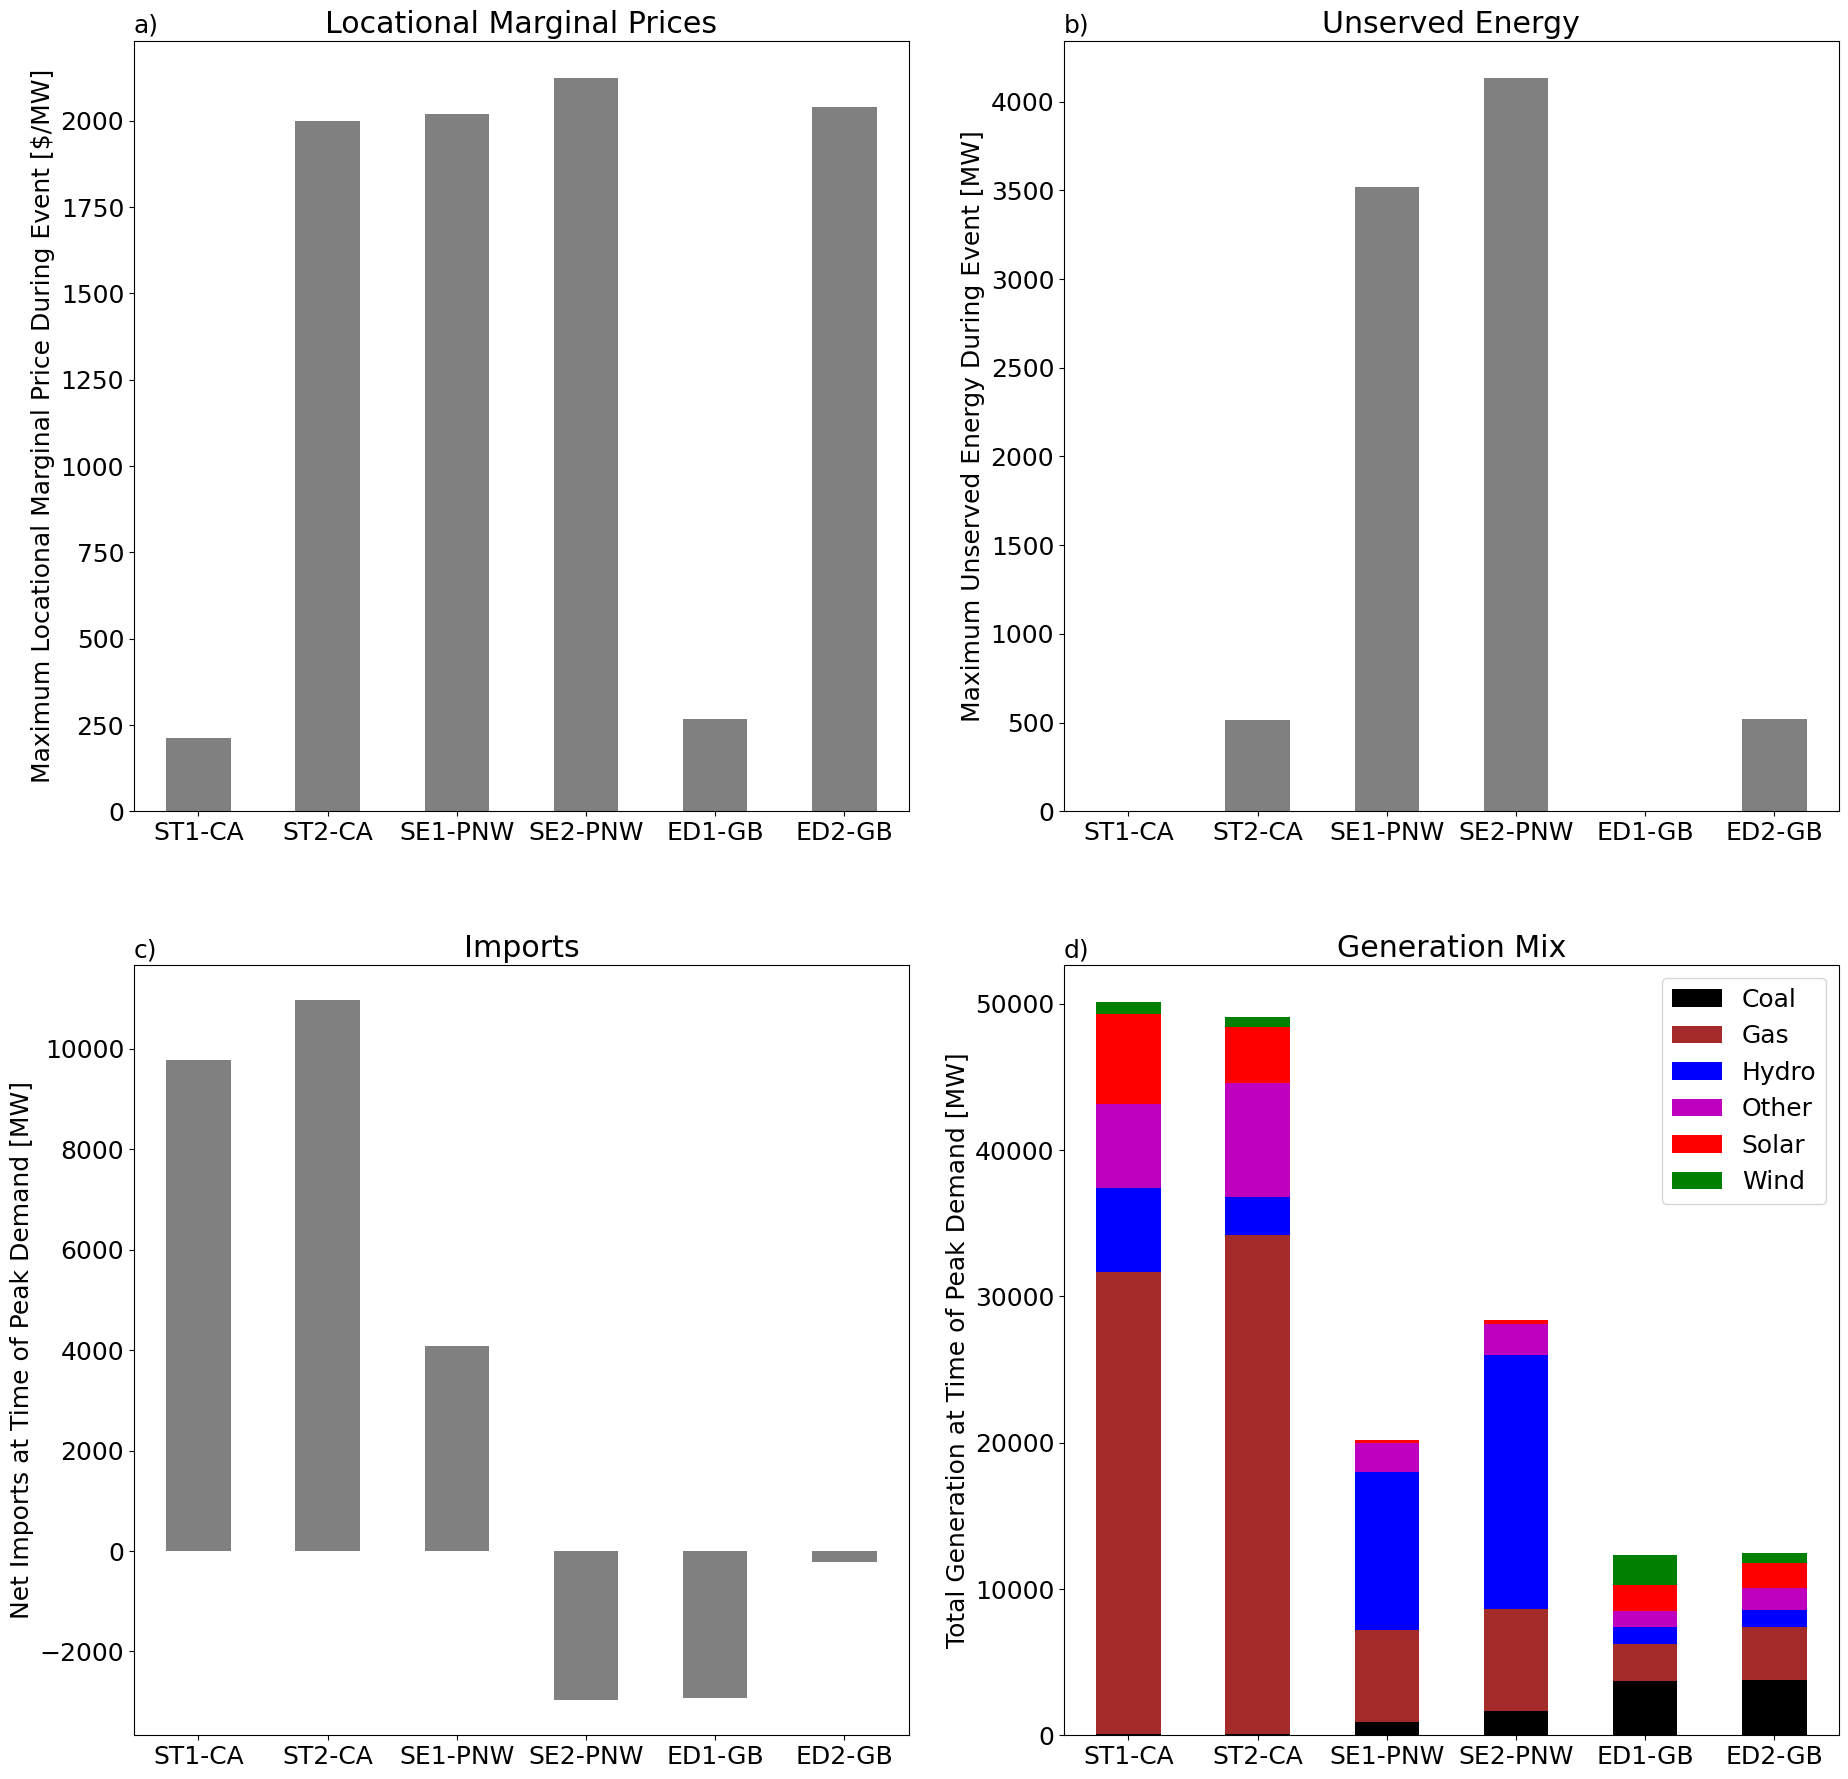

In [139]:
# Test the function:
output_df = plot_case_studies(event_list = ['HW_NERC1_Event58', 'HW_NERC1_Event78', 'HW_NERC11_Event93', 'HW_NERC11_Event64', 'HW_NERC4_Event70', 'HW_NERC4_Event17'],
                              event_label = ['ST1-CA', 'ST2-CA', 'SE1-PNW', 'SE2-PNW', 'ED1-GB', 'ED2-GB'],
                              hw_cs = 'HW',
                              events_data_input_dir = events_data_input_dir,
                              image_output_dir = image_output_dir, 
                              image_resolution = 150,
                              save_images = True)

output_df
